In [77]:
#!/usr/bin/env python

import os
import glob

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator


import pandas as pd

import json

from pathlib import Path
home = str(Path.home())

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
plt.rcParams.update({'font.size': 18})

In [78]:
from plot_transit_time import transit_params, degg_list,extract_fit_params,extract_temperature,extract_histogram,extract_device


In [79]:
colorsCustom = ['#8dd3c7','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69','#fccde5','#d9d9d9','#bc80bd','#ccebc5','#ffed6f','#1f78b4','#33a02c','#e31a1c','#a6cee3','#b2df8a','#fb9a99','#fdbf6f','#ff7f00','#cab2d6','#ffff99','#6a3d9a','#b15928','#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02','#a6761d','#666666','#1f78b4']


In [80]:
def extract_run_number(json_file):
    with open(json_file, 'r') as f:
        data = json.load(f)
    return data["run_number"]

In [81]:
plotFolder = home+"/research_ua/icecube/Upgrade/timing_calibration/plots/degg_transit"
degg_list = [f.path for f in os.scandir(home+"/research_ua/icecube/upgrade/timing_calibration/data/degg_transit/") if f.is_dir()]

In [82]:
degg_tt_file = '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/scripts/degg_transit_times.json'

In [83]:
def extract_json(transit_time_file,obj_key) -> list:
    '''
    Reads the json file with the list of DOMs and transit time measurements and returns a list of transit times
    and other data values
    for chi2, object key : "chi2"
    for transit time, object key:"mu"

    '''
    data_values = []
    degg_list_from_json = []    
    with open(transit_time_file, 'r') as f:
        data = json.load(f)
        for degg, tt_data in data.items():
            degg_list_from_json.append(degg)            
            for ichannel in tt_data["transit_times"]:
                if len(tt_data["transit_times"]) > 2:
                    print(f"len {len(tt_data["transit_times"])}")
                for itt in tt_data["transit_times"][ichannel]:
                    if len(itt) > 0:
                        data_values.append(itt[obj_key])
                    if itt["sigma"] > 10:
                        print(degg)
                        print(ichannel)
                        print(itt["sigma"])
                        print(itt["chi2"])
    print(len(degg_list_from_json))
    return data_values

In [84]:
degg_tts = extract_json(degg_tt_file,"sigma")

200


In [85]:
def plot_transit_time_spread_histogram(transit_times_spread,bins) -> None:
    fig = plt.figure(figsize=(8,5))
    gs = gridspec.GridSpec(nrows=1,ncols=1)
    ax = fig.add_subplot(gs[0])
    ax.hist(transit_times_spread, bins=bins,histtype='step',color=colorsCustom[0],linewidth=1.5 ,label=r'tts', alpha=1)
    ax.tick_params(axis='both',which='both', direction='in', labelsize=22)
    ax.set_xlabel(r"time [ns]", fontsize=22)
    ax.set_ylabel(r"count", fontsize=22)
    ax.set_yscale('log')
    ax.text(0.95, 0.95, fr"tts: {np.mean(transit_times_spread):.1f}"+r"$\pm$" + fr" {np.std(transit_times_spread):.1f}  ns", transform=ax.transAxes, ha='right', va='top')
    ax.grid(True,alpha=0.6)
    ax.set_xlim(0,5)
    # ax.set_xlim(xlim[0],xlim[1])
    ax.legend(fontsize=22,ncols=1)
    plt.show()
    plt.close()

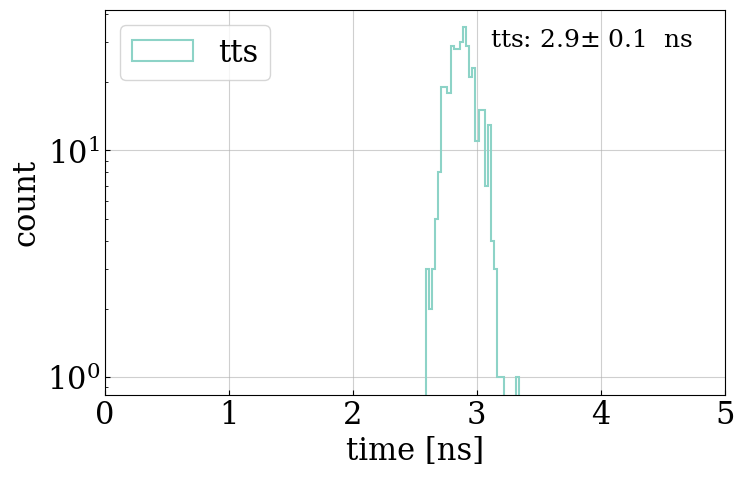

In [86]:
plot_transit_time_spread_histogram(degg_tts,30)

In [87]:
print(len(degg_tts))

371
